In [4]:
import pandas as pd

df = pd.read_csv("../Data/feature_engineering.csv")
df[["Day_Type","Peak_Hour","Delivery_Performance","Profit_Margin_Percentage","Customer_Age_Group"]]

,Day_Type,Peak_Hour,Delivery_Performance,Profit_Margin_Percentage,Customer_Age_Group
0,Weekend,True,Slow,0.006245,Youth
1,Weekday,True,Fast,0.009899,Adult
2,Weekend,True,Slow,0.010855,Adult
3,Weekday,False,Slow,0.001921,Adult
4,Weekend,False,Normal,0.034091,Senior
...,...,...,...,...,...
99995,Weekday,True,Slow,0.128788,Adult
99996,Weekday,False,Normal,0.000000,Adult
99997,Weekday,True,Fast,0.022795,Adult
99998,Weekday,False,Normal,0.022202,Adult


In [ ]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Delivery_Time_Min', 'Distance_km', 'Order_Value',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Cancellation_Reason', 'Delivery_Partner_ID', 'Delivery_Rating',
       'Restaurant_Rating', 'Order_Day', 'Peak_Hour', 'Profit_Margin',
       'Calculated_Amount', 'Day_Type', 'Profit_Margin_Percentage',
       'Customer_Age_Group', 'Delivery_Performance'],
      dtype='str')

Customer_ID
CUST1606    54910.320505
CUST4431    54068.131388
CUST5267    53746.660252
CUST5534    51561.810883
CUST1239    51426.810883
CUST8740    51384.301261
CUST6252    51333.980757
CUST8797    51136.301261
CUST6706    50193.490378
CUST2910    50048.810883
Name: Final_Amount, dtype: float64


Text(0, 0.5, 'Total Spending')

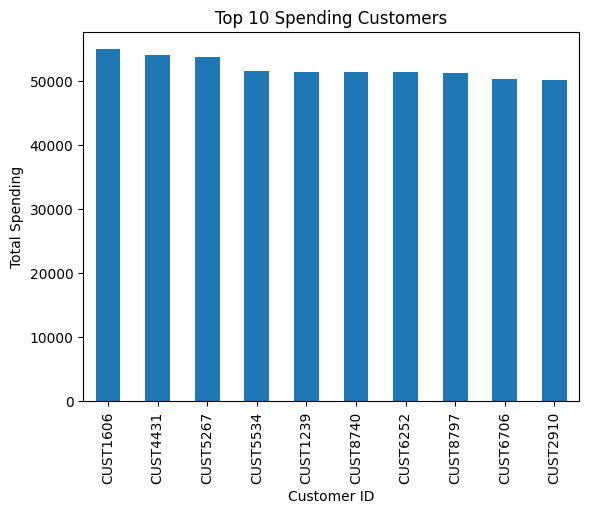

In [9]:
import matplotlib.pyplot as plt
top_customers = df.groupby("Customer_ID")["Final_Amount"].sum().sort_values(ascending = False).head(10)
print(top_customers)
plt.figure()
top_customers.plot(kind = "bar")
plt.title("Top 10 Spending Customers") 
plt.xlabel("Customer ID") 
plt.ylabel("Total Spending")



Very Close Spending Range
Small Gap Between Rank 1 and Rank 10
The top 10 customers show a relatively uniform spending pattern between ₹50,000–₹55,000, indicating a strong and stable premium customer segment rather than dependency on a single outlier

Business Idea:

Launch a Gold / Elite Membership Program for customers spending above ₹50,000 annually.
Early access to offers

In [13]:
Age_wise_spending = df.groupby("Customer_Age_Group")["Final_Amount"].mean()
Age_wise_spending

Customer_Age_Group
Adult     2004.466826
Senior    2001.224643
Youth     2000.664310
Name: Final_Amount, dtype: float64

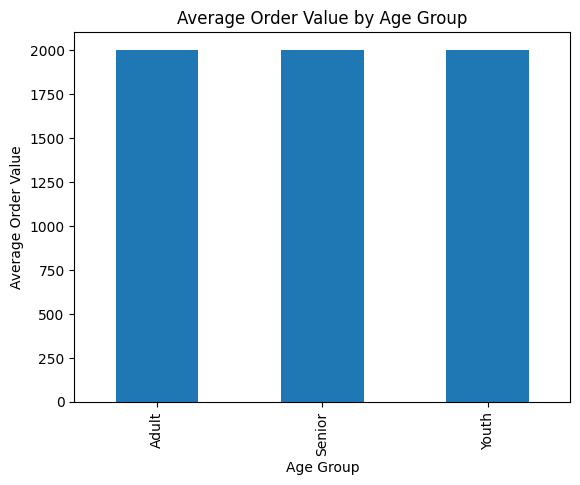

In [14]:
plt.figure()
Age_wise_spending.plot(kind="bar")
plt.title("Average Order Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Order Value")
plt.show()

Age group does not significantly impact order value.
Spending behavior is uniform across age segments
All groups spend roughly ₹2000 per order.
Age Is Not a Strong Revenue Driver

Business Idea:

Since all age groups spend similarly (~₹2000): Maintain consistent pricing strategy
Improve Product Personalization
Example:
Younger customers → Fast food, late night
Older customers → Healthy food, early evening

In [16]:
week_analysis = df.groupby("Day_Type")["Order_ID"].count()
week_analysis

Day_Type
Weekday    71632
Weekend    28368
Name: Order_ID, dtype: int64

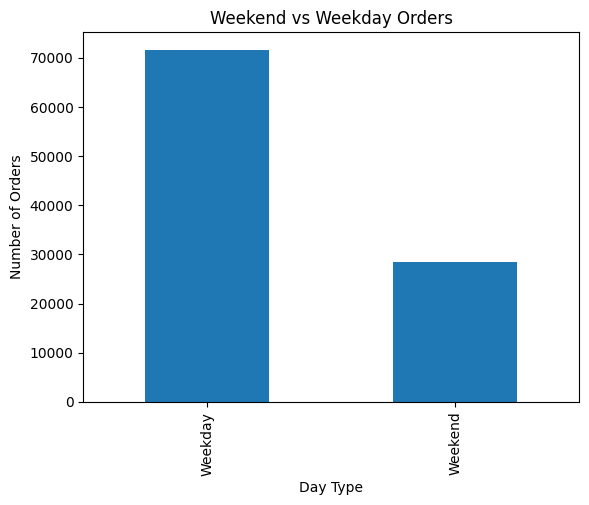

In [17]:
plt.figure()
week_analysis.plot(kind="bar")
plt.title("Weekend vs Weekday Orders")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")
plt.show()

Order volume is significantly higher on weekdays
To increase sales on weekends,Targeted weekend campaigns, family meal combos, and promotional pricing could help improve weekend demand.

Business Idea:
Since weekdays are already strong, focus only on boosting weekends:

Weekend Mega Saver
Saturday Feast Combo
Sunday Family Treat


In [25]:
import pandas as pd
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.month
monthly_revenue = df.groupby("Month")["Final_Amount"].sum()
monthly_revenue

Month
1     1.703962e+07
2     1.581897e+07
3     1.672486e+07
4     1.620551e+07
5     1.680197e+07
6     1.646264e+07
7     1.924446e+07
8     1.653322e+07
9     1.651596e+07
10    1.652012e+07
11    1.634196e+07
12    1.615025e+07
Name: Final_Amount, dtype: float64

Text(0, 0.5, 'Total Revenue')

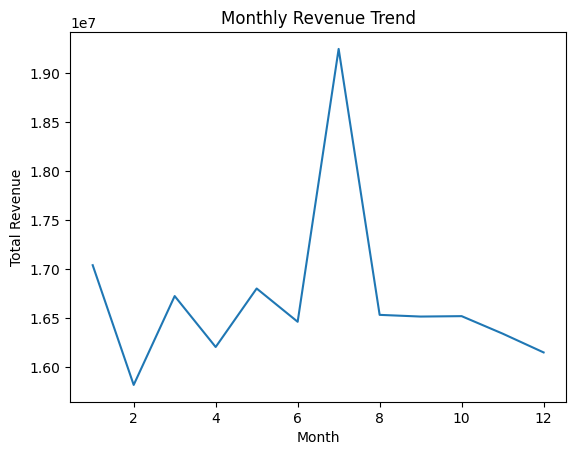

In [30]:
plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")


July (Month 7) Is Peak Revenue Month,February Is Lowest Revenue Month
Overall Trend Is Stable (Except July),Not permanent growth

Business Idea:

Instead of giving heavy discounts in July:

Introduce premium bundles

Launch new product items

Reduce marketing spend in July

Increase marketing spend in February

In [32]:
discount_analysis = df.groupby("Discount_Applied")["Profit_Margin"].mean()
discount_analysis

Discount_Applied
0.0      0.178352
20.0     0.177937
50.0     0.177609
100.0    0.180167
300.0    0.180608
Name: Profit_Margin, dtype: float64

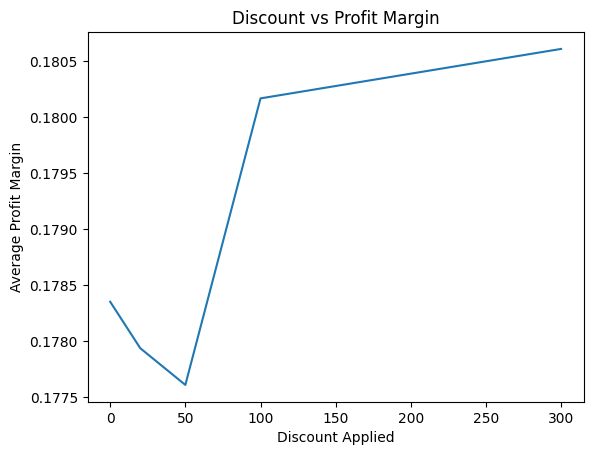

In [33]:
plt.figure()
discount_analysis.plot()
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount Applied")
plt.ylabel("Average Profit Margin")
plt.show()

Discounts Are Not Significantly Reducing Profit Margin
That is a VERY small difference between lowest and highest.0.1806 − 0.1776 ≈ 0.003 only
Business is not losing profit due to discounts

Business idea:
Instead of using discounts randomly:

Give coupons to inactive users

Offer comeback discounts

Increase discount during low months (February)

Reduce discount during peak month (July)

In [36]:
city_cuisine_revenue = (
    df.groupby(["City", "Cuisine_Type"])["Final_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
city_cuisine_revenue 

City       Cuisine_Type
hyderabad  indian          2.256670e+07
           arabian         1.131589e+07
chennai    indian          1.130819e+07
bangalore  indian          1.128904e+07
delhi      indian          1.122118e+07
hyderabad  italian         1.119047e+07
mumbai     indian          1.112417e+07
hyderabad  mexican         1.106377e+07
           chinese         1.105672e+07
bangalore  mexican         5.739909e+06
Name: Final_Amount, dtype: float64

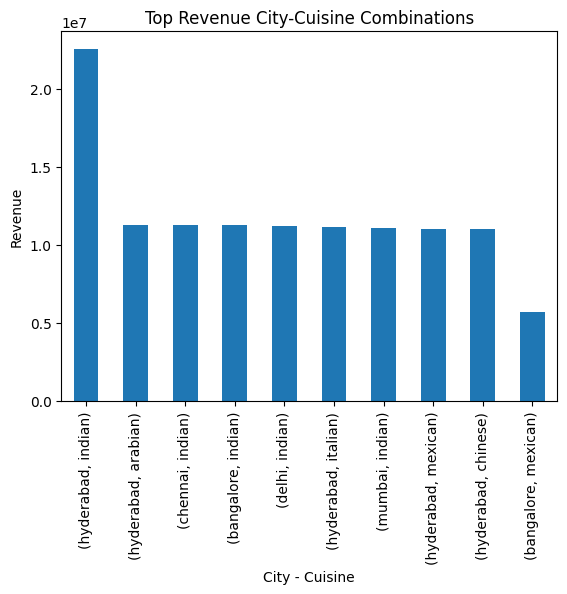

In [37]:
plt.figure()
city_cuisine_revenue.plot(kind="bar")
plt.title("Top Revenue City-Cuisine Combinations")
plt.xlabel("City - Cuisine")
plt.ylabel("Revenue")
plt.show()

Hyderabad Is The Revenue Powerhouse,Indian cuisine in Hyderabad is a dominant revenue engine.
Indian Cuisine Dominates Across India
Mexican is stronger in Hyderabad than Bangalore.

Business idea :
Since Hyderabad generates the highest revenue: Use Hyderabad as a testing and scaling center.
Since Indian cuisine dominates across cities: 

Expand Indian cuisine restaurant partnerships

Introduce premium Indian thali combos

In [38]:
Avg_delivery_Time = df.groupby("City")["Delivery_Time_Min"].mean()
Avg_delivery_Time

City
bangalore    126.851718
chennai      127.011439
delhi        127.413427
hyderabad    127.583681
mumbai       128.416680
Name: Delivery_Time_Min, dtype: float64

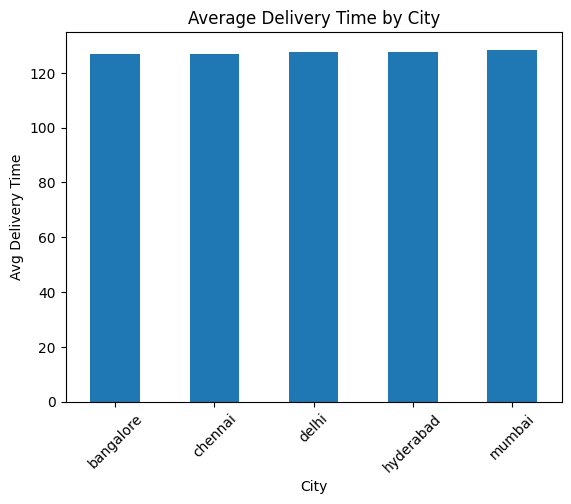

In [39]:
plt.figure()
Avg_delivery_Time.plot(kind="bar")
plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Avg Delivery Time")
plt.xticks(rotation=45)
plt.show()

Delivery time is almost the same across all cities
Mumbai is slightly slower
Bangalore is slightly faster
Delivery time distance is very small

Business Idea : 

Since delivery time variation is minimal:Builds customer trust and brand positioning.

Mumbai is slightly slower. Increase delivery partners during peak hours, Optimize route allocation

In [44]:
df["Distance_Group"] = pd.cut(df["Distance_km"], bins=4)

distance_summary = df.groupby("Distance_Group")["Delivery_Time_Min"].mean()
distance_summary

Distance_Group
(0.961, 10.75]    127.335467
(10.75, 20.5]     128.197636
(20.5, 30.25]     127.882315
(30.25, 40.0]     127.384608
Name: Delivery_Time_Min, dtype: float64

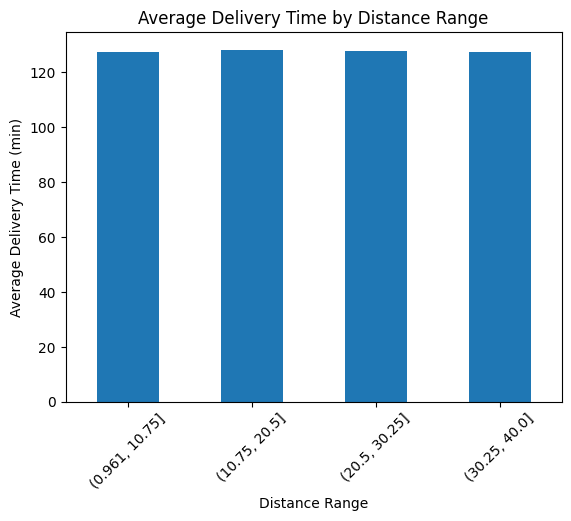

In [45]:
plt.figure()
distance_summary.plot(kind="bar")
plt.title("Average Delivery Time by Distance Range")
plt.xlabel("Distance Range")
plt.ylabel("Average Delivery Time (min)")
plt.xticks(rotation=45)
plt.show()

Delivery time is almost SAME for all distances. Distance is NOT strongly affecting delivery time,
indicating that distance is not the main factor influencing delivery delay

Business Idea : 
Time is stable regardless of distance. Promote this as:

“Fast delivery no matter how far you are.”

In [46]:
Delivery_analysis = df.groupby("Delivery_Performance")["Delivery_Rating"].mean()
Delivery_analysis

Delivery_Performance
Fast      2.536775
Normal    2.554503
Slow      2.542109
Name: Delivery_Rating, dtype: float64

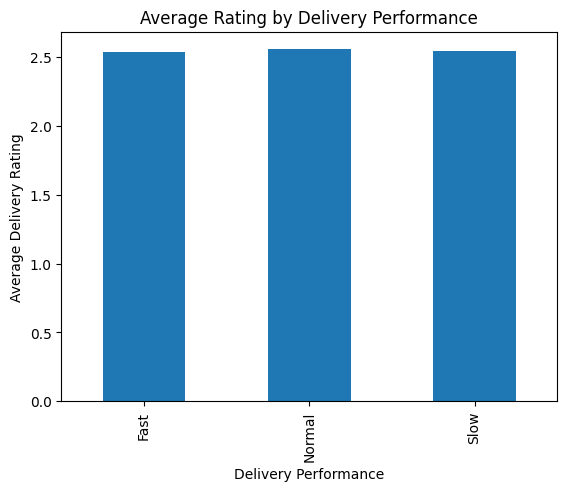

In [50]:
plt.figure()
Delivery_analysis.plot(kind="bar")
plt.title("Average Rating by Delivery Performance")
plt.xlabel("Delivery Performance")
plt.ylabel("Average Delivery Rating")
plt.show()

In [49]:
top_restaurants = df.groupby("Restaurant_ID")["Delivery_Rating"].mean().sort_values().head(10)
top_restaurants 

Restaurant_ID
RES218    2.042735
RES864    2.056075
RES174    2.079646
RES901    2.123894
RES384    2.139344
RES231    2.156250
RES200    2.160377
RES874    2.160377
RES455    2.160714
RES279    2.163265
Name: Delivery_Rating, dtype: float64

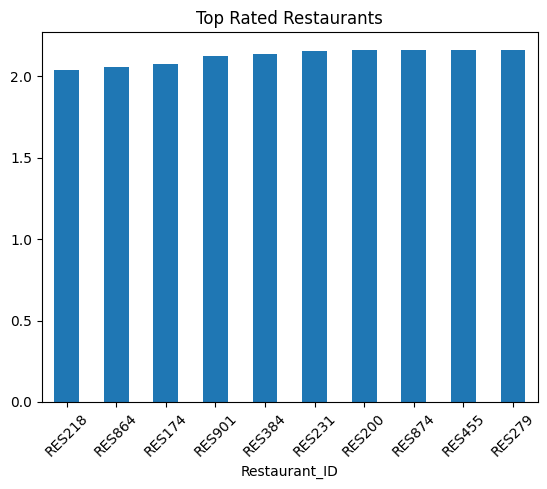

In [51]:
plt.figure()
top_restaurants.plot(kind="bar")
plt.title("Top Rated Restaurants")
plt.xticks(rotation=45)
plt.show()

After filtering restaurants with sufficient order volume, these 10 restaurants have the lowest average ratings, indicating consistent service quality issues rather than random low ratings.



In [58]:
cancel_rate = df[df["Order_Status"] == "cancelled"].groupby("Restaurant_Name")["Order_ID"].count()
cancel_rate

Restaurant_Name
Restaurant_1      28
Restaurant_10     35
Restaurant_100    35
Restaurant_101    28
Restaurant_102    30
                  ..
Restaurant_95     30
Restaurant_96     29
Restaurant_97     31
Restaurant_98     33
Restaurant_99     28
Name: Order_ID, Length: 500, dtype: int64

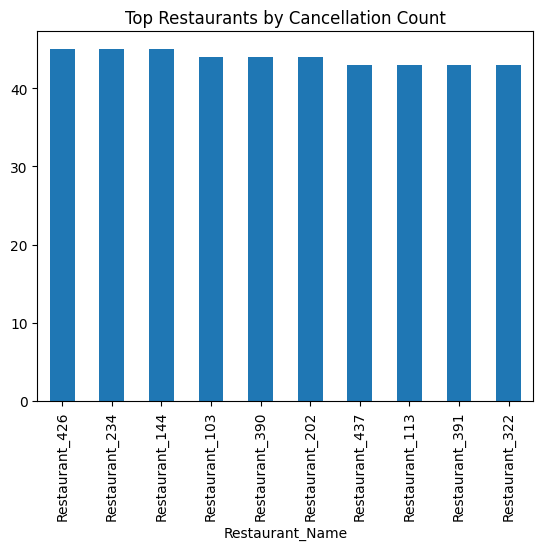

In [60]:
plt.figure()
cancel_rate.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Restaurants by Cancellation Count")
plt.show()

Cancellation counts per restaurant range between 28 and 35, indicating a relatively uniform distribution of cancelled orders across the 500 restaurants. No individual restaurant shows extreme cancellation behavior based on raw counts

Since no single restaurant has extreme cancellation:
Focus on:

Delivery optimization

Real-time order tracking

Platform communication improvement

Instead of penalizing individual restaurants blindly.

In [61]:
cuisine_perf = df.groupby("Cuisine_Type")["Final_Amount"].sum()
cuisine_perf

Cuisine_Type
arabian    3.315124e+07
chinese    3.331941e+07
indian     6.750928e+07
italian    3.307233e+07
mexican    3.330727e+07
Name: Final_Amount, dtype: float64

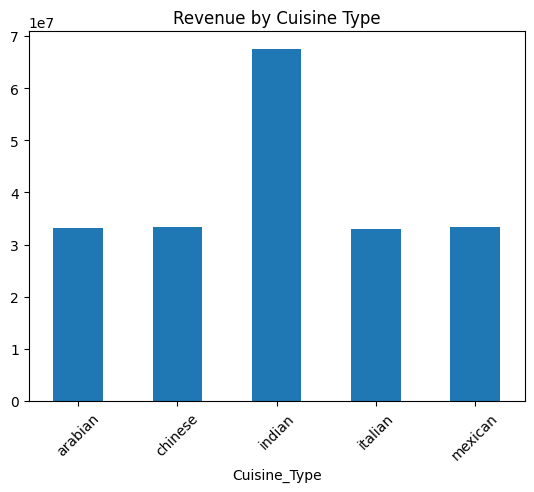

In [62]:
plt.figure()
cuisine_perf.plot(kind="bar")
plt.title("Revenue by Cuisine Type")
plt.xticks(rotation=45)
plt.show()

Indian cuisine is the primary revenue driver of the platform.Other Cuisines perform very similarly in terms of revenue.This indicates strong market preference and strategic importance of Indian cuisine in overall business performance.

Since Indian cuisine drives most revenue:

Business Idea:

Prioritize onboarding top-rated Indian restaurants

Feature Indian cuisine prominently on homepage

Launch “India’s Favorite Dishes” campaign

Create premium regional Indian collections

Protect and strengthen your strongest segment first.

In [63]:
payment_mode = df.groupby("Payment_Mode")["Order_ID"].count()
payment_mode

Payment_Mode
card      40005
cod       19977
upi       19932
wallet    20086
Name: Order_ID, dtype: int64

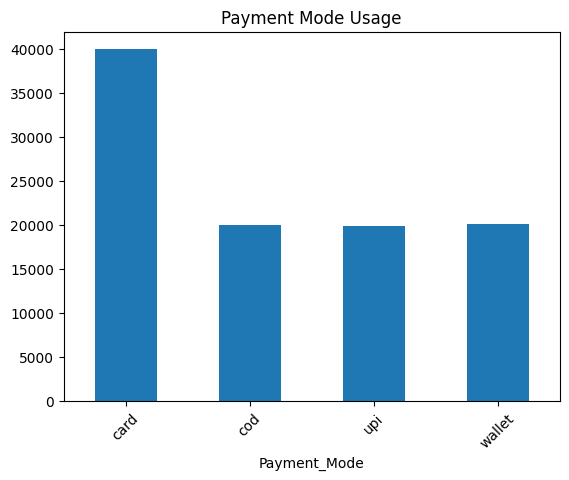

In [64]:
plt.figure()
payment_mode.plot(kind="bar")
plt.title("Payment Mode Usage")
plt.xticks(rotation=45)
plt.show()

Card payment is Dominating.Customers prefer digital card payments over COD, UPI, or Wallet.COD, UPI, Wallet Are Almost Equal 

Since card is dominant: Make dominant method even smoother → increases conversion rate.

In [66]:
cancel_reason = df[df["Order_Status"] == "cancelled"].groupby("Cancellation_Reason")["Order_ID"].count()
cancel_reason

Cancellation_Reason
customer cancelled    2993
late delivery         3059
not cancelled         6005
restaurant issue      2979
Name: Order_ID, dtype: int64

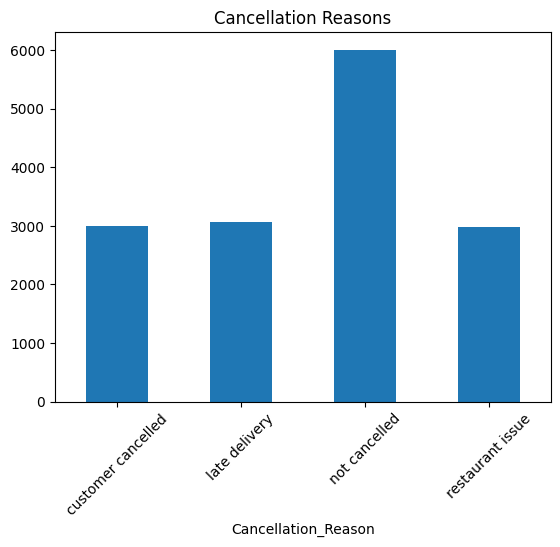

In [67]:
plt.figure()
cancel_reason.plot(kind="bar")
plt.title("Cancellation Reasons")
plt.xticks(rotation=45)
plt.show()

Late delivery is the top cancellation driver.Cancellations are almost evenly distributed across 3 major causes, with slight dominance of late delivery.

Business Idea:

Introduce Predictive Delay Alerts

Notify customer if order may be late

Offer instant ₹50 wallet credit before cancellation

Provide live tracking transparency